# Reading in data

In [1]:
import pandas as pd 
import numpy as np
import re
import matplotlib.pyplot as plt
import math

In [2]:
df_25_26 = pd.read_csv('data/25_26_survey.csv')
df_24_25 = pd.read_csv('data/24_25_survey.csv')
df_23_24 = pd.read_csv('data/23_24_survey.csv')

In [3]:
df_25_26.shape

(137, 90)

In [4]:
df_24_25.shape

(145, 90)

In [5]:
df_23_24.shape

(318, 85)

# 23-24 Analysis

In [6]:
# Carlie did some great work on analyzing the data. I will be branching some of these ideas into a new notebook to expore them further. 

## Data Cleaning 

In [7]:
# Dropping garbage columns that we don't need.
df = df_23_24.drop(columns=['Timestamp',
                            'Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!   By submitting your name below you will receive an additional point for the 2023-2024 Housing Lottery.',
                            'Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!   By submitting your name below you will receive an additional point for the 2023-2024 Housing Lottery..1'])

# Cleaning up meal plan question because it was a free form response  
valid_plans = {
    "All Access 7",
    "All Access 5",
    "Block 160",
    "Block 100",
    "Block 50",
    "Commuter 80",
    "Commuter 300"
}

# The meal plan column is messy, so we need to clean that up. 
# Normalizing meal plan responses to match valid plans. 
def normalize_meal_plan(x):
    if pd.isna(x):
        return np.nan
    
    s = str(x).lower().strip()
    s = re.sub(r'[^a-z0-9\s]', '', s)
    s = re.sub(r'\s+', ' ', s)

    if any(k in s for k in ["no meal", "dont", "don't", "own food", "rather not"]):
        return np.nan

    if re.search(r'\b7\b|seven|aa7|full|largest|unlimited', s):
        return "All Access 7"
    
    if re.search(r'\b5\b|five', s):
        return "All Access 5"

    if "160" in s:
        return "Block 160"
    if "100" in s:
        return "Block 100"
    if "50" in s:
        return "Block 50"

    if "80" in s:
        return "Commuter 80"
    if "300" in s:
        return "Commuter 300"

    return np.nan

# Cleaning up meal plan column
df["meal_plan_clean"] = df["What meal plan do you have?"].apply(normalize_meal_plan)
df["meal_plan_clean"].value_counts(dropna=False)

meal_plan_clean
All Access 5    122
Block 50         63
NaN              60
All Access 7     53
Block 100        13
Block 160         6
Commuter 80       1
Name: count, dtype: int64

## Random Ideas

In [8]:
# Chat GPT helped me figure out a way to think about breaking up these 
# questions into cateogories for analysis. We can support 3 
# specific areas of campus with this config:

# Operational performance
# ======================
# RA effectiveness
# Residence Life staff effectiveness
# Programming value
# Facilities & maintenance
# Safety & security
# Dining satisfaction

# Student success & retention drivers
# ===================================
# Sense of belonging
# Community climate
# Outcomes of living on campus
# Weekend engagement & programming demand

# Strategic planning
# ==================
# Building/floor experience differences
# Athlete vs non-athlete experience
# First-year vs upperclass experience
# Meal plan satisfaction & improvement opportunities

# So next, we engineer some features that will give us scores for 
# RA, staff, safety, facitities/services, community on campus, 
# & outcome of living on campus 

## Feature Engineering

In [9]:
# Converting "agree" type responses to numeric
likert_map = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

for col in df.columns:
    df[col] = df[col].replace(likert_map)

C:\Users\bdupey\AppData\Local\Temp\ipykernel_64576\1372187417.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(likert_map)


In [10]:
# Identifying RA columns 
ra_cols = [c for c in df.columns if 'RA' in c and 'rate' in c]
df['RA_score'] = df[ra_cols].mean(axis=1)
ra_cols

['Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
 'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of information about campus & community resources]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA treats me with respect]',
 'Please read the following statements regarding your fall semester RA and rate them. [The RAs are consistent with regards to policy violations]',
 'Please read the following statements regarding your fa

In [11]:
# Assiging a staff score 
staff_cols = [c for c in df.columns if 'Residence Life staff' in c and 'Please share any additional comments' not in c]
df['staff_score'] = df[staff_cols].mean(axis=1)
staff_cols

['Please read the following statements regarding Residence Life staff and rate them. Residence Life staff includes Hall Directors (HD),  Assc. Director of Residence Life (Jori Van Beek), and Director of Residence Life (Robby Patterson). [My Hall Director has made an effort to be present in the building and get to know the residents in my community]',
 'Please read the following statements regarding Residence Life staff and rate them. Residence Life staff includes Hall Directors (HD),  Assc. Director of Residence Life (Jori Van Beek), and Director of Residence Life (Robby Patterson). [I know how to contact my HD if I have questions or need assistance]',
 'Please read the following statements regarding Residence Life staff and rate them. Residence Life staff includes Hall Directors (HD),  Assc. Director of Residence Life (Jori Van Beek), and Director of Residence Life (Robby Patterson). [Residence Life staff members are easy to contact when needed]',
 'Please read the following statement

In [12]:
# Creating safety score 
safety_cols = [c for c in df.columns if 'safety' in c.lower() and 'Please provide any additional feedback' not in c]
df['safety_score'] = df[safety_cols].mean(axis=1)
safety_cols

['Please read the following statements regarding safety and rate them. [I know how to contact Campus Security]',
 'Please read the following statements regarding safety and rate them. [When I contact Campus Security I know they will be able to help me]',
 'Please read the following statements regarding safety and rate them. [I feel safe in my room and on campus]',
 'Please read the following statements regarding safety and rate them. [I feel my belongings are safe in my room]',
 'Please read the following statements regarding safety and rate them. [I feel safe walking alone on campus at night]']

In [13]:
fac_cols = [c for c in df.columns if 'Facilities & Services' in c]
df['facilities_score'] = df[fac_cols].mean(axis=1)
fac_cols

['Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the cleanliness of my residence hall]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the internet connectivity in my room]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the laundry room facilities in my hall]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the lounges in my hall]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [It is easy to study in my hall without noise interruptions]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I can sleep without interruption in my hall]',
 'Please read the following statements rega

In [14]:
community_cols = [c for c in df.columns if 'community on campus' in c]
df['community_score'] = df[community_cols].mean(axis=1)
community_cols

['Please read the following statements regarding the community on campus and rate them. [I feel a strong sense of community among the people living in my residence hall]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing races/ethnicity]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing genders]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of different sexual orientations]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing religious beliefs]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing political views]',
 'Please read the following statements regarding t

In [15]:
outcome_cols = [c for c in df.columns if 'outcome of living on campus' in c]
df['outcome_score'] = df[outcome_cols].mean(axis=1)
outcome_cols

['Please read the following statements regarding the outcome of living on campus and rate them. [My ability to make friends was enhanced by living on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [My ability to participate in campus organizations / athletics / events was enhanced by living on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to manage my time because of living on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am a better problem solver because I have lived on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to lead others because I have lived on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to take responsibility for my action

## Exploratory Data Analysis

### Checking Distributions of Numeric Values

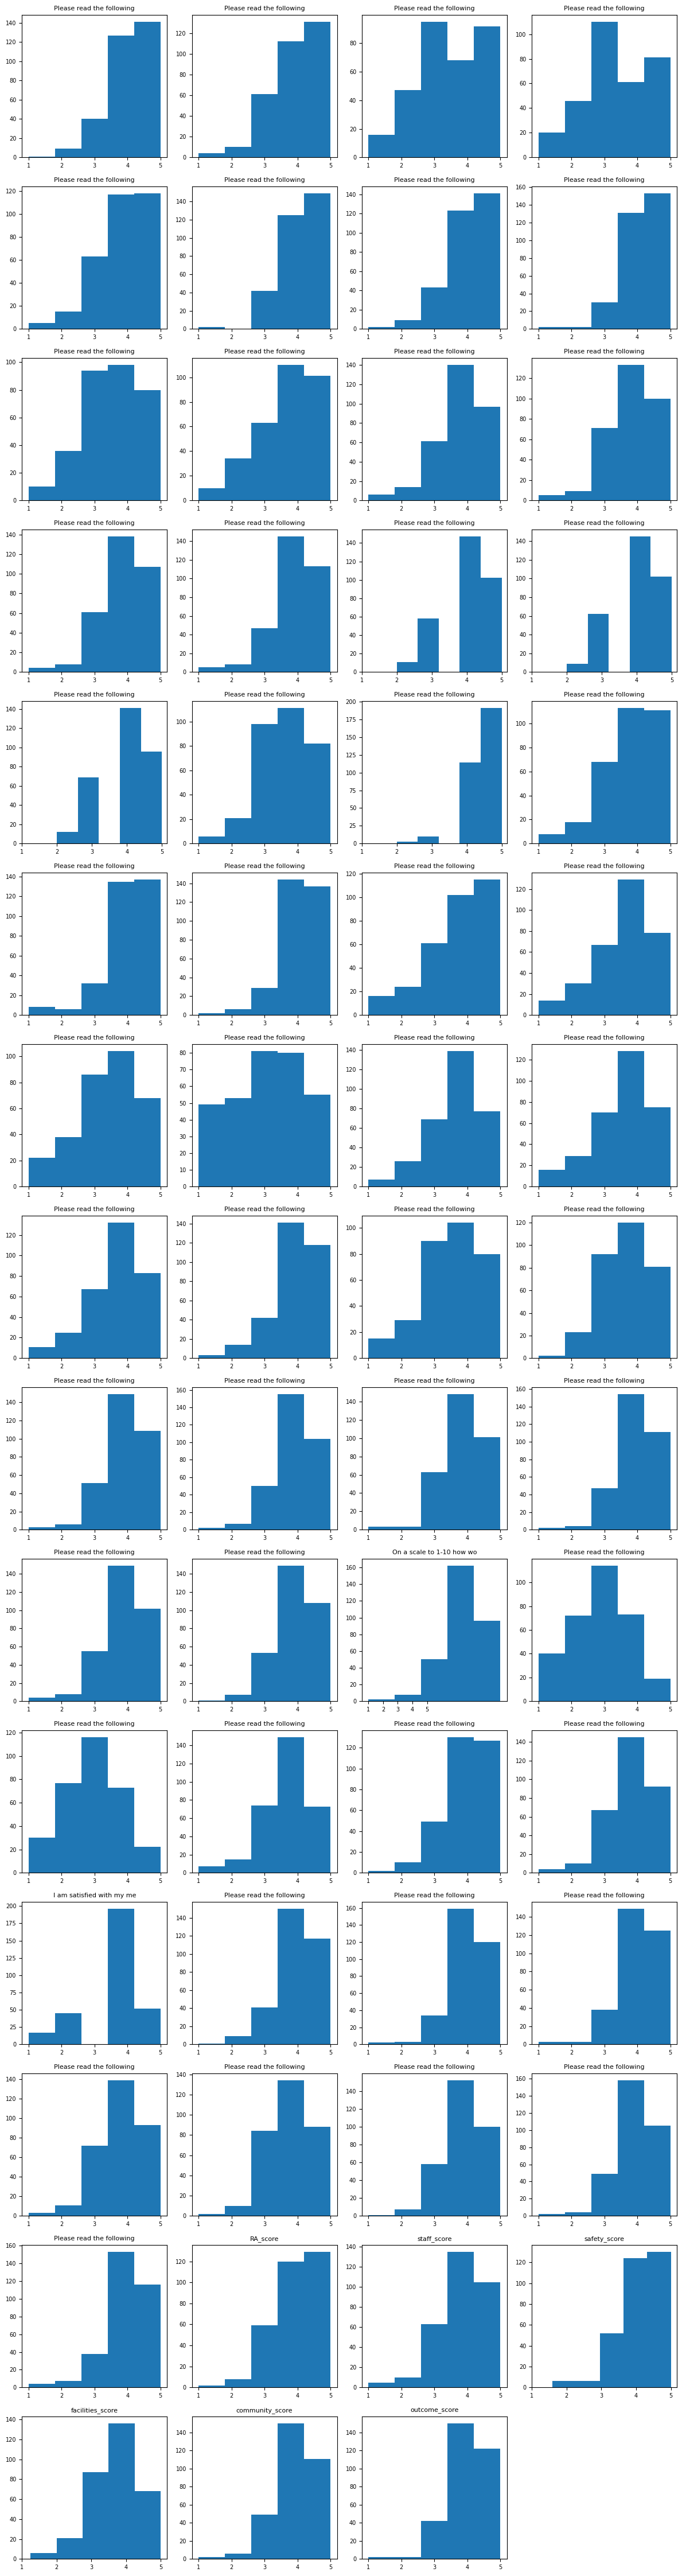

In [16]:
num_cols = df.select_dtypes(include='number').columns
cols = list(num_cols)
n = len(cols)
ncols = 4  # adjust for width preference
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=5)
    ax.set_title(col[:25], fontsize=8)  # truncate long names
    ax.set_xticks([1,2,3,4,5])
    ax.tick_params(labelsize=7)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [17]:
# Lotta left skewed distributions here. Meaning we didn't hear as much from people who had negative experiences. 
# This is pretty common in survey data, but it does mean we need to be careful about how we interpret the results. 
# We can also look at the distribution of our engineered features to see if they are more normally distributed. 

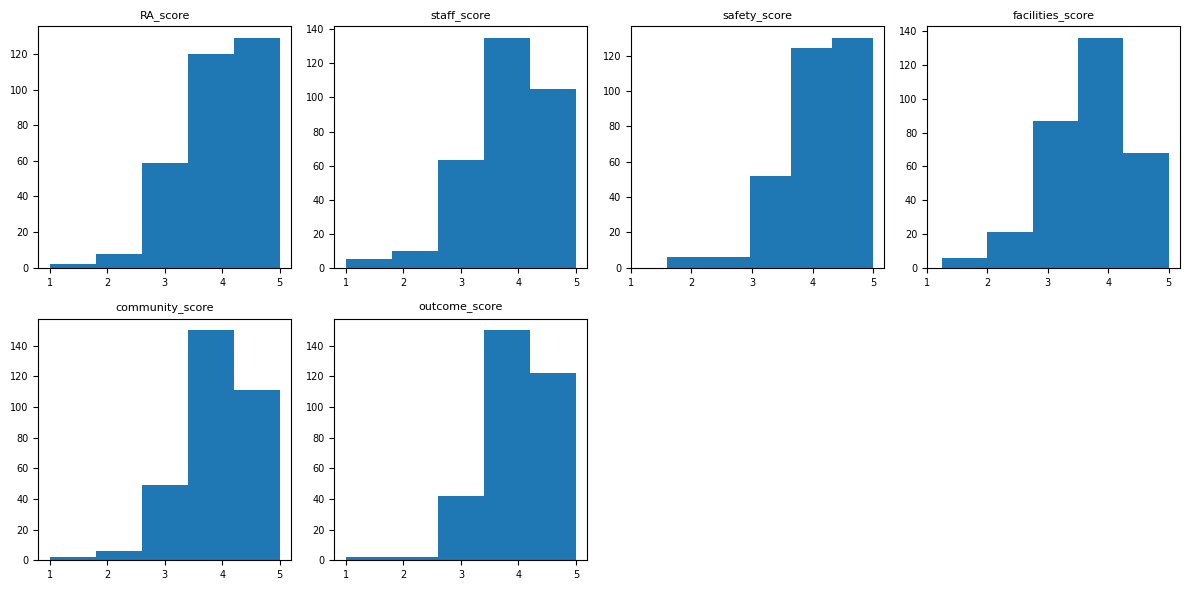

In [18]:
import math
import matplotlib.pyplot as plt

# numeric columns containing "score"
cols = [
    c for c in df.select_dtypes(include='number').columns
    if 'score' in c.lower()
]

n = len(cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=5)
    ax.set_title(col[:25], fontsize=8)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.tick_params(labelsize=7)

# remove unused panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
# Scores are also pretty left skewed, as well. 


## Score analysis

In [20]:
df[['RA_score','staff_score','safety_score',
    'facilities_score','community_score','outcome_score']].mean().sort_values()
# Looks like facilities scores the lowest, then staff. RA, community, outcome, and safety are 
# all pretty close to each other. 

facilities_score    3.670991
staff_score         3.928197
RA_score            4.035377
community_score     4.061995
outcome_score       4.113208
safety_score        4.172956
dtype: float64

In [21]:
df.corr(numeric_only=True)['On a scale to 1-10 how would your rate your sense of belonging / connection to Grand View University']\
  .sort_values(ascending=False)

On a scale to 1-10 how would your rate your sense of belonging / connection to Grand View University                                                                                                                                                                                                                                                            1.000000
Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus has created a sense of belonging at Grand View University]                                                                                                                                                                                      0.552511
outcome_score                                                                                                                                                                                                                                                                         

In [22]:
df.groupby('Which Residence Hall did you live in during the fall semester?')['facilities_score'].mean().sort_values()
# Nielsen has the lowest facilities score. 

Which Residence Hall did you live in during the fall semester?
Nielsen Hall       3.394737
Knudsen Hall       3.521552
Hull Apartments    3.640625
L Apartments       3.661972
Hull Suites        3.732639
Langrock Suites    3.828947
Name: facilities_score, dtype: float64

In [23]:
df.groupby('Do you participate on a Grand View Athletic team?')['community_score'].mean()
# Athletes have a higher community score on average. Not surprising, but good to see it in the data.

Do you participate on a Grand View Athletic team?
No     3.853741
Yes    4.136752
Name: community_score, dtype: float64

In [24]:
df.groupby('What is your Class Status?')['RA_score'].mean()
# First years have a much higher RA score on average. Again, not surprising, but good to see it in the data.

What is your Class Status?
Freshman     4.150000
Junior       4.064063
Senior       3.942857
Sophomore    3.922194
Name: RA_score, dtype: float64

In [25]:
df.groupby('How many semesters have you lived on campus at Grand View?')['community_score'].mean()
# Interesting, the community score is highest for people in their first 2 semesters, then it drops off and is 
# lowest for people in their 5th+ semester. This could be a sign that people who have lived on campus longer 
# are more likely to have had negative experiences that have impacted their sense of community. Or it could be 
# that people who have lived on campus longer are more likely to be upperclassmen who are less engaged in the 
# community. This is something we can explore further with qualitative data or by looking at other variables in the survey.

How many semesters have you lived on campus at Grand View?
1-2 Semesters    4.172878
3-4 Semesters    4.007143
5+ Semesters     3.916667
Name: community_score, dtype: float64

In [26]:
score_cols  = [c for c in df.columns if 'score' in c]
score_cols

['RA_score',
 'staff_score',
 'safety_score',
 'facilities_score',
 'community_score',
 'outcome_score']

In [27]:
df.groupby('Which Residence Hall did you live in during the fall semester?')[score_cols]\
  .mean()\
  .sort_values(by=score_cols[0], ascending=False)

,RA_score,staff_score,safety_score,facilities_score,community_score,outcome_score
Which Residence Hall did you live in during the fall semester?,,,,,,
Langrock Suites,4.246711,3.993421,4.160526,3.828947,4.214286,4.314145
Hull Apartments,4.097656,4.010417,4.125000,3.640625,4.102679,3.945312
Nielsen Hall,4.042763,3.785088,4.352632,3.394737,3.943609,4.095395
L Apartments,4.031690,3.805164,4.033803,3.661972,4.058350,4.126761
Knudsen Hall,3.961207,3.925287,4.310345,3.521552,4.024631,4.043103
Hull Suites,3.814236,4.020833,4.194444,3.732639,3.964286,4.000000


### Score by Residence Hall Analysis

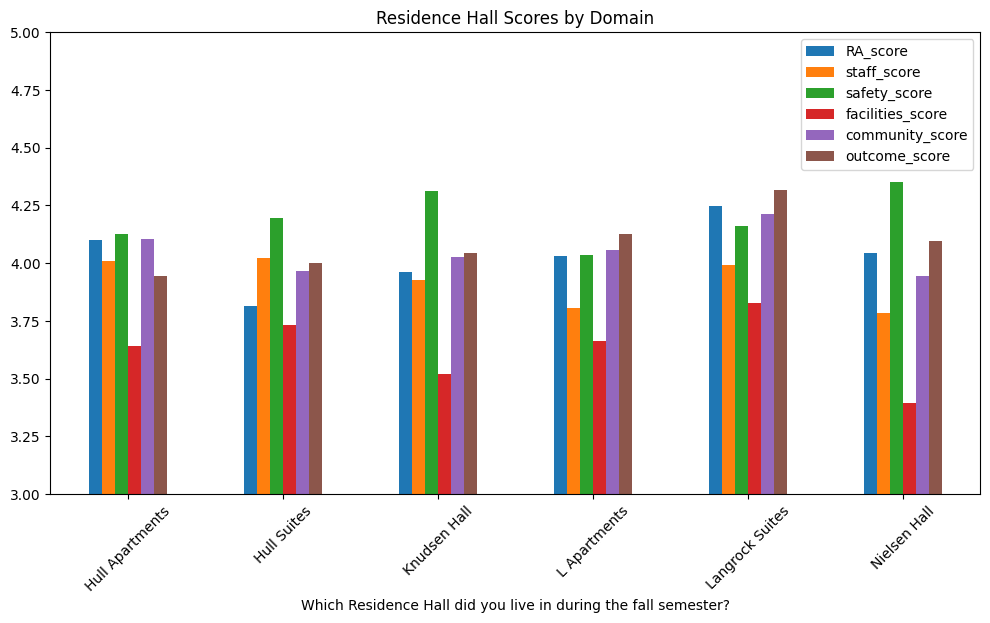

In [28]:
hall_scores = (
    df.groupby('Which Residence Hall did you live in during the fall semester?')[score_cols]
      .mean()
      .sort_index()
)
lowest = hall_scores.idxmin()
hall_scores.plot(kind='bar', figsize=(12,6))
plt.ylim(3,5)
plt.title("Residence Hall Scores by Domain")
plt.xticks(rotation=45)
plt.show()

In [29]:
df['Which Residence Hall did you live in during the fall semester?'].value_counts()

Which Residence Hall did you live in during the fall semester?
Langrock Suites    76
Hull Suites        72
L Apartments       71
Nielsen Hall       38
Hull Apartments    32
Knudsen Hall       29
Name: count, dtype: int64

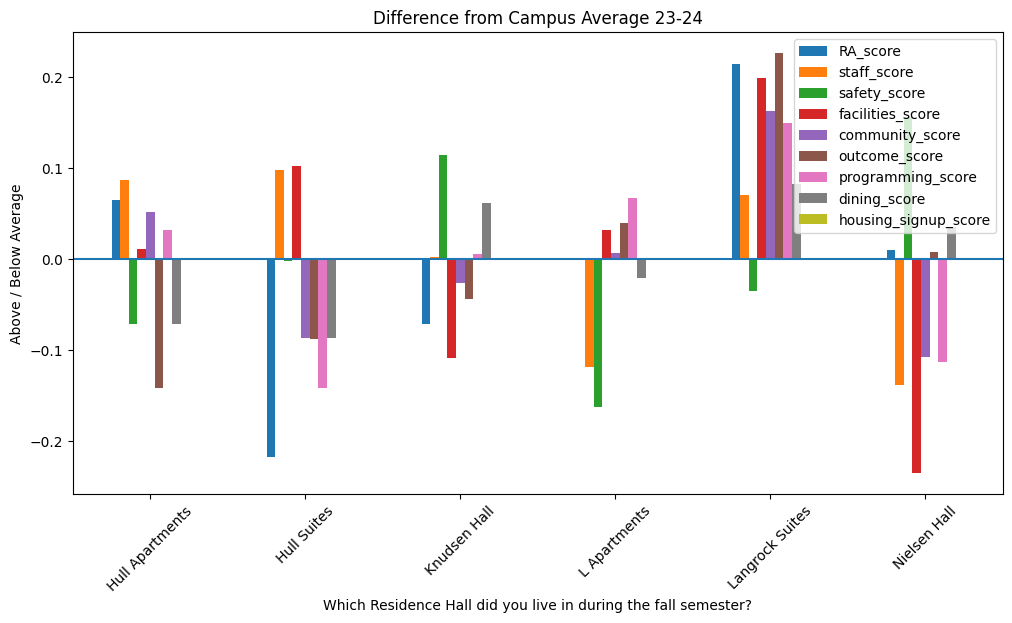

In [65]:
diff = hall_scores - hall_scores.mean()

diff.plot(kind='bar', figsize=(12,6))
plt.axhline(0)
plt.title("Difference from Campus Average 23-24")
plt.ylabel("Above / Below Average")
plt.xticks(rotation=45)
plt.show()

In [31]:
# HULL APARTMENTS
# BELOW AVG IN OUTCOME 

# HULL SUITES 
# BELOW AVERAGE IN RA SCORES

# KNUDSEN 
# Good safety scores 

# L Apartments 
# Lowest safety scores and low staff scores.

# Langrock
# Above average on all scores. They're doing something right. 

# NIELSEN
# Lowest on facilities, staff, and community scores. But high on safety.

In [32]:
df[outcome_cols].mean().sort_values()

Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to lead others because I have lived on campus]                                             3.930818
Please read the following statements regarding the outcome of living on campus and rate them. [I am a better problem solver because I have lived on campus]                                                3.968553
Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to take responsibility for my actions because I have lived on campus]                      4.078616
Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus had a positive impact on my academic success]                                              4.132075
Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus has created a sense of belonging at Gran

In [33]:
df['Please read the following statements regarding Residence Life programming and rate them. [I would be more likely to stay on campus over the weekend if programs / events were provided more often on Friday / Saturday]'].mean()
# This is interesting. It seems like there is a decent amount of demand for more weekend programming, 
# which could be an opportunity for Residence Life to increase engagement and retention. We could also 
# look at the distribution of responses to this question to see if there are any patterns (e.g. do first 
# years want more weekend programming than upperclassmen?).

np.float64(3.761006289308176)

In [34]:
df['What meal plan do you have?'].unique()

array(['Block 50', nan, '50 block', '100', '50 swipes ',
       'The 50 swipes or whatever is the lowest option. ', 'BLOCK 50',
       'block 150', '50', '7days', 'block 100', '7 Day ', '5 day',
       "I don't even know ", 'Block 160', 'Block 100',
       '5 day all access ', '5 day meal plan', '5 block', '7 day',
       'All-Access 7', 'all access 5 ', 'All access 5', '5 day ',
       '5 day mean plan ', 'All-Access 5', '5-Day All Access', 'access 5',
       '5 day all access', '7 days all acess', 'all access 5',
       'All-access 5', '5 day pass', '5 day meal plan ', 'All Access 5',
       'All Acsess 5', 'I have the 5 day a week plan ', 'Access all 5 ',
       'full', '7 Day All Access', '5 days a week', 'all 5 ', 'acces 5',
       'All-Access 7 ', 'All access 7', 'All Access 7',
       'I have the largest one', '3 day ', '7 day a week ', '5-day', '7',
       '5 days ', '5 day access', 'all-5 access ', 'All-access ',
       'block 5 ', 'All 7', '7 day ', 'Full meal plan ', 'block 

In [35]:
df.groupby('meal_plan_clean')['I am satisfied with my meal plan'].mean().sort_values(ascending=True)
# Not surprisingly, the All Access 7 plan has the highest satisfaction, followed by All Access 5. 
# The block plans have lower satisfaction, with Block 50 being the lowest. The commuter plans have 
# the lowest satisfaction overall. This could be due to a variety of factors, such as the value 
# provided by the meal plan, the needs of the students on those plans, or other factors. This 
# is something we can explore further with qualitative data or by looking at other variables 
# in the survey.

meal_plan_clean
Block 50        3.507937
All Access 5    3.606557
Block 100       3.615385
All Access 7    4.038462
Block 160       4.500000
Commuter 80     5.000000
Name: I am satisfied with my meal plan, dtype: float64

In [36]:
dining_cols = ['Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the food quality on campus]',
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]',
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in GV Express]',
 "Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of options provided at Einstein's Bagels ]",
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the level of customer service I receive from GV Dining employees]',
 'I am satisfied with my meal plan']
df[dining_cols].mean().sort_values()
# Looks like the lowest rated aspect of dining is the variety & quality of options at Einstein's Bagels, followed by the variety & quality of food at GV Express. 
# The highest rated aspect is the level of customer service from GV Dining employees. This could be an opportunity for improvement in the dining options, 
# particularly at Einstein's Bagels and GV Express. We could also look at the distribution of responses to these questions to see if there are any patterns 
# (e.g. do people on certain meal plans have different satisfaction levels with dining?).


Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the food quality on campus]                                                  2.871069
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]    2.937107
I am satisfied with my meal plan                                                                                                                                            3.712903
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in GV Express]                        3.836478
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the level of customer service I receive from GV Dining employees]            3.977987
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with 

In [37]:
col = 'What are the main areas that positively impact your sense of belonging / connection to Grand View University'

belonging = (
    df[[col, 'community_score']]
    .dropna(subset=[col])
    .assign(area=lambda d: d[col].str.split(','))
    .explode('area')
)

belonging['area'] = belonging['area'].str.strip()

belonging.groupby('area')['community_score'] \
    .agg(['mean','count']) \
    .sort_values('mean', ascending=False)


# Looking at which impacts having the sense of belonging the most. 

# Very strong signals
# Having a mentor on campus shows the highest association with community belonging.
# Residential community experience is a major driver of connection.
# REC/SAC events and intramural participation are strongly associated with higher community scores.
# Positive relationships with coaches and structured team environments strengthen belonging.
# Athletic participation is the dominant connection pathway due to both strong scores and high participation.

# Less strong signals: 
# Campus clubs/orgs (~3.80)
# Choir/Band/Performances (~3.77)
# Academic extracurriculars (~3.66)

# 6 at-risk individuals who reported "No sense of belonging or connect at Grand View at all" as a positive impact on their sense of belonging.

# Key takeaways
# Belonging is strongest where relationships and structured involvement intersect.
# Athletics and residential living function as primary engines of student connection.
# Mentorship appears to be a high-impact, scalable belonging intervention.
# Clubs and academic extracurriculars show weaker connection signals and may need strengthening.
# A small group reporting no sense of belonging represents an early retention risk.

,mean,count
area,,
Having a mentor on campus,4.459184,14
Your residential community,4.267081,46
Participating in REC/SAC events,4.250000,52
Positive relationships with your coaches,4.238095,102
Participating in intramural sports,4.222222,18
Involvement in an athletic team,4.122024,192
Campus Size,4.120690,116
Campus Location,4.114719,66
Your campus job,4.065637,37


In [38]:
df.groupby('What are the main areas that positively impact your sense of belonging / connection to Grand View University')['community_score'].mean()

What are the main areas that positively impact your sense of belonging / connection to Grand View University
Campus Location                                                                                                                                              5.000000
Campus Location, Participating in intramural sports                                                                                                          5.000000
Campus Size, Campus Location                                                                                                                                 3.357143
Campus Size, Campus Location, Your residential community, Participating in REC/SAC events                                                                    5.000000
Friends                                                                                                                                                      3.142857
                                                             

In [39]:
df.groupby('How many residence life programs/events did you attend this school year')['community_score'].mean()

How many residence life programs/events did you attend this school year
1-2 events    3.958525
3-4 events    4.294833
5+ events     4.121212
Name: community_score, dtype: float64

## Summing up what we know so far.

In [40]:
# I think that grouping columns is a good idea. We need a way to make different surveys "talk to each other".
# So we can group questions into the collowing categories: Operational Performance, Student Success & Retention Drivers, 
# and Strategic Planning. This will help us structure our analysis and recommendations in a way that 
# is actionable for the Residence Life team.

# Key findings: 

# OPERATIONAL PERFORMANCE
# =======================
# RA Score, Staff Score, Safety Score, Facitilites Score
# =======================

# Most of our survey questions got a 4 or more on average, which is a good sign. It means that most students 
# are generally satisfied with their experience living on campus.    

# We generated a facilities score, staff score, RA score, community score, outcomes score, and 
# safety score. The largest area of focus were the facilities and staff scores. The two best areas were 
# outcomes and safety scores. 

# Nielsen and Knudsen got the lowest facilities scores.

# Overall satisfaction is high; most scores fall between ~3.8 and 4.2.
# Safety is the strongest dimension across all halls.
# Facilities is the weakest area and shows the most variation.
# Nielsen Hall has the lowest facilities score but strong safety ratings.
# Langrock Suites is the most consistently strong overall.
# Differences between halls are modest; improvements to facilities may have the greatest impact.

# Meal plan satisfaction was highest with commuter 80 and lowest with 50 block, 
# all access 5, and block 100.
# Biggest complaints about food are food quality and variety on campus. 


# STUDENT SUCCESS & RETENTION DRIVERS
# ===============================
# Outcomes score, community score 
# ===============================
# Living on campus is highly correlated with a sense of belonging, community on campus.

# Athletics have a higher sense of community and belonging. 

# Community scores are at their highest in the first 2 semeseters, then drop off. 
# This could be a sign that students who have lived on campus longer are more 
# likely to have had negative experiences that have impacted their sense of 
# community. Or it could be that students who have lived on campus longer are 
# more likely to be upperclassmen who are less engaged in the community. This 
# is something we can explore further with qualitative data or by looking at 
# other variables in the survey?

# There's a strong correlation between community scores 
# attendance at RL events. So this is a way to potentially
# increase community scores and retention.  

# STRATEGIC PLANNING
# ========
# No Score s
# ========

# There was interest in living on the weekend if more programming was offered. 

# Next Steps:
# ============
# NEXT STEPS
# ============

# I think that if Isabella can try to do some of this work for 25-26 and Carlie can dig into freeform text responses,
# we probably have enough to bring home a presentation. We want to talk to the 3 main areas of focus in a powerpoint.
# In each of these, we want to say "This was who responded to the survey", "This is what we found to be positive", 
# "This is what we found to be a potential area of improvement", and "Here are some research-backed reccomendations
# for how to imrove that things". So that will be our end-goal. 

# # TODO for Isabella: 
# Look at year over year trend analysis that I did for 24-25. 

# Maybe start to compare the notes between the two years to see if 
# you can find any consistent improvements, declines, or 
# things that have stayed consistently good/bad between the two years? 

# We want to spin this into some kind of story where we talk about
# what the survey told us is going well, what the survey told us is not going well, and then
# what we can do about it. So maybe start to piece that puzze together. 

# # TODO for Carlie

# There are 6 people who marked "No sense of belonging or connect at 
# Grand View at all" when asked "What are the main areas that positively impact 
# your sense of belonging / connection to Grand View University"
# Could you investigate these 6 individuals? Sounds like they might be at risk
# and I'd be interested to know what else they have to say. 

# • Free-text themes to review.
#   - facilities issues (cleanliness, maintenance, aging spaces)
#   - food quality, variety, value
#   - staff responsiveness and support
#   - RA engagement and programming effectiveness
#   - belonging, inclusion, and community climate
#   - reasons upperclassmen feel less connected
#   - interest in weekend programming and social opportunities

# Also maybe look at the free responses to see what people
# like the most about RL events, since that increased our 
# community score a lot. You might also look for things like 
# mentorship or positive comments about sports, as well.

# L Apartments has the lowest safety score and 71 of the respondents 
# were from there. Maybe call out any safety concerns or see if there are 
# consistent comments coming from people in L Apartments about safety. 
# Knudsen had the highest safety score. Maybe look for any positive comments about safety coming from Knudsen.


# Nielsen hall had the lowest facilities, community, and staff scores. 
# See if any negative comments coming from that building have consisitencies.

# Hull apartment has lower than average outcome scores. Looks like it's driven 
# by people who want more leadership experiences or problem solving experiences.
# Again, maybe something to look for in the comments? 

# Hull suites had way lower scores for RAs. Might also be something to lok into. 

# You may need to just go through these and read them. Sometimes that's easier with a smaller sample size. 
# Let me know if you want help breaking up the questions. We essentially want to give more details on the 
# problematic and good areas from the survey, so we can present numbers, present qualitative info, and then
# give some kind of recommendation to administration. 



# 24-25 Analysis

## Cleaning DAta 

In [41]:
import re
import numpy as np
import pandas as pd

# Make keys lowercase to match s.lower()
likert_map = {
    "strongly disagree": 1,
    "disagree": 2,
    "neutral": 3,
    "agree": 4,
    "strongly agree": 5,
    "not applicable": np.nan,
    "n/a": np.nan,
    "na": np.nan
}


def standardize_likert(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().lower()
    return likert_map.get(s, np.nan if s in likert_map else x)

def convert_likert_columns(df):
    out = df.copy()
    for c in out.columns:
        if out[c].dtype == "object":
            out[c] = out[c].map(standardize_likert)
    return out

DOMAIN_RULES = {
    "RA_score": [
        r"regarding you fall semester ra and rate them",
        r"regarding your fall semester ra and rate them"
    ],
    "staff_score": [r"residence life staff and rate them"],
    "programming_score": [r"residence life programming and rate them"],
    "safety_score": [r"regarding safety and rate them"],
    "facilities_score": [r"residence life facilities\s*&\s*services and rate them"],
    "community_score": [r"regarding the community on campus and rate them"],
    "dining_score": [r"regarding gv dining and rate"],
    "housing_signup_score": [r"housing sign-up process and rate them"],
    "outcome_score": [r"regarding the outcome of living on campus and rate them"],
}

def find_domain_columns(columns, patterns):
    cols = []
    for col in columns:
        col_l = str(col).strip().lower()
        for pat in patterns:
            if re.search(pat, col_l):
                cols.append(col)
                break
    return cols

def add_composite_scores(df, min_items=2):
    out = df.copy()
    domain_cols = {}

    for domain, patterns in DOMAIN_RULES.items():
        cols = find_domain_columns(out.columns, patterns)
        domain_cols[domain] = cols

        if len(cols) >= min_items:
            # Force numeric (anything not converted becomes NaN)
            numeric_block = out[cols].apply(pd.to_numeric, errors="coerce")
            out[domain] = numeric_block.mean(axis=1)
        else:
            out[domain] = np.nan

    score_cols = list(DOMAIN_RULES.keys())
    return out, domain_cols, score_cols

df2 = convert_likert_columns(df)
df2, domain_cols, score_cols = add_composite_scores(df2, min_items=2)

# QA: how many items per scale, and how many non-numeric survived
for k, cols in domain_cols.items():
    if len(cols) == 0:
        print(k, "0 items matched")
    else:
        non_numeric = df2[cols].apply(lambda s: pd.to_numeric(s, errors="coerce")).isna().sum().sum()
        print(k, "items:", len(cols), "| total non-numeric cells coerced to NaN:", int(non_numeric))

RA_score items: 8 | total non-numeric cells coerced to NaN: 0
staff_score items: 6 | total non-numeric cells coerced to NaN: 0
programming_score items: 4 | total non-numeric cells coerced to NaN: 0
safety_score items: 5 | total non-numeric cells coerced to NaN: 0
facilities_score items: 8 | total non-numeric cells coerced to NaN: 0
community_score items: 7 | total non-numeric cells coerced to NaN: 0
dining_score items: 5 | total non-numeric cells coerced to NaN: 0
housing_signup_score 0 items matched
outcome_score items: 8 | total non-numeric cells coerced to NaN: 0


In [42]:
df2.head()

,What is your Class Status?,How many semesters have you lived on campus at Grand View?,Are you currently 21 or older?,Do you participate on a Grand View Athletic team?,Which Residence Hall did you live in during the fall semester?,What floor did you live on during the fall semester?,Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA],Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA],Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me],Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people],...,meal_plan_clean,RA_score,staff_score,safety_score,facilities_score,community_score,outcome_score,programming_score,dining_score,housing_signup_score
0,Junior,5+ Semesters,No,Yes,Hull Apartments,2nd Floor,4,4,3,2,...,Block 50,3.50,3.000000,3.6,3.750,2.857143,3.750,4.5,4.0,NaN
1,Junior,3-4 Semesters,No,Yes,Hull Apartments,1st Floor,3,3,2,2,...,Block 50,2.75,4.000000,4.0,3.625,3.142857,3.625,3.5,2.8,NaN
2,Junior,5+ Semesters,No,Yes,Hull Apartments,2nd Floor,5,5,5,5,...,NaN,5.00,5.000000,4.4,5.000,5.000000,5.000,5.0,3.0,NaN
3,Senior,5+ Semesters,Yes,Yes,Hull Apartments,3rd Floor,5,5,5,3,...,Block 50,4.75,4.333333,3.8,2.875,3.714286,3.875,3.5,3.4,NaN
4,Junior,1-2 Semesters,No,No,Hull Apartments,1st Floor,5,5,5,5,...,Block 50,5.00,4.000000,4.8,4.250,3.285714,3.875,5.0,3.8,NaN


## Score analysis

In [43]:
df2[['RA_score','staff_score','safety_score',
    'facilities_score','community_score','outcome_score']].mean().sort_values()
# Very similar to last years

facilities_score    3.670991
staff_score         3.928197
RA_score            4.035377
community_score     4.061995
outcome_score       4.113208
safety_score        4.172956
dtype: float64

In [44]:
df2.columns

Index(['What is your Class Status?',
       'How many semesters have you lived on campus at Grand View?',
       'Are you currently 21 or older?',
       'Do you participate on a Grand View Athletic team?',
       'Which Residence Hall did you live in during the fall semester?',
       'What floor did you live on during the fall semester?',
       'Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of

In [45]:
df2.columns

Index(['What is your Class Status?',
       'How many semesters have you lived on campus at Grand View?',
       'Are you currently 21 or older?',
       'Do you participate on a Grand View Athletic team?',
       'Which Residence Hall did you live in during the fall semester?',
       'What floor did you live on during the fall semester?',
       'Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of

In [46]:
df2.corr(numeric_only=True)['On a scale to 1-10 how would your rate your sense of belonging / connection to Grand View University']\
  .sort_values(ascending=False)

# Even higher community score in 2025-25 data, yay!

On a scale to 1-10 how would your rate your sense of belonging / connection to Grand View University                                                                                                                       1.000000
Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus has created a sense of belonging at Grand View University]                                                 0.552511
outcome_score                                                                                                                                                                                                              0.549289
Please read the following statements regarding the outcome of living on campus and rate them. [My ability to make friends was enhanced by living on campus]                                                                0.546565
community_score                                                                         

In [47]:
df2.groupby('Which Residence Hall did you live in during the fall semester?')['facilities_score'].mean().sort_values()
# Nielsen has the lowest facilities score. 

Which Residence Hall did you live in during the fall semester?
Nielsen Hall       3.394737
Knudsen Hall       3.521552
Hull Apartments    3.640625
L Apartments       3.661972
Hull Suites        3.732639
Langrock Suites    3.828947
Name: facilities_score, dtype: float64

In [48]:
# Nielsen facilities went up and went to top. But most others decreased this year. 


In [49]:
df2.groupby('Do you participate on a Grand View Athletic team?')['community_score'].mean()
# Athletes had a higher community score on average last year, but this has incrased among 
# non athletes in 25-26. 

Do you participate on a Grand View Athletic team?
No     3.853741
Yes    4.136752
Name: community_score, dtype: float64

In [50]:
df2.groupby('What is your Class Status?')['RA_score'].mean().sort_values()

What is your Class Status?
Sophomore    3.922194
Senior       3.942857
Junior       4.064063
Freshman     4.150000
Name: RA_score, dtype: float64

In [51]:
df2[df2['What is your Class Status?']=='Grad Student'].shape

(0, 92)

In [52]:
# Grad students have the lowest RA scores, but there are only 3 of
# them in this survey. It'd be interesting to know what they said.

In [53]:
df2.groupby('How many semesters have you lived on campus at Grand View?')['community_score'].mean()
# Community scores decreased with newer students this year. 

How many semesters have you lived on campus at Grand View?
1-2 Semesters    4.172878
3-4 Semesters    4.007143
5+ Semesters     3.916667
Name: community_score, dtype: float64

In [54]:
score_cols  = [c for c in df2.columns if 'score' in c]
score_cols

['RA_score',
 'staff_score',
 'safety_score',
 'facilities_score',
 'community_score',
 'outcome_score',
 'programming_score',
 'dining_score',
 'housing_signup_score']

In [55]:
df2.groupby('Which Residence Hall did you live in during the fall semester?')[score_cols]\
  .mean()\
  .sort_values(by=score_cols[0], ascending=False)

,RA_score,staff_score,safety_score,facilities_score,community_score,outcome_score,programming_score,dining_score,housing_signup_score
Which Residence Hall did you live in during the fall semester?,,,,,,,,,
Langrock Suites,4.246711,3.993421,4.160526,3.828947,4.214286,4.314145,4.118421,3.642105,NaN
Hull Apartments,4.097656,4.010417,4.125000,3.640625,4.102679,3.945312,4.000000,3.487500,NaN
Nielsen Hall,4.042763,3.785088,4.352632,3.394737,3.943609,4.095395,3.855263,3.594737,NaN
L Apartments,4.031690,3.805164,4.033803,3.661972,4.058350,4.126761,4.035211,3.538028,NaN
Knudsen Hall,3.961207,3.925287,4.310345,3.521552,4.024631,4.043103,3.974138,3.620690,NaN
Hull Suites,3.814236,4.020833,4.194444,3.732639,3.964286,4.000000,3.826389,3.472222,NaN


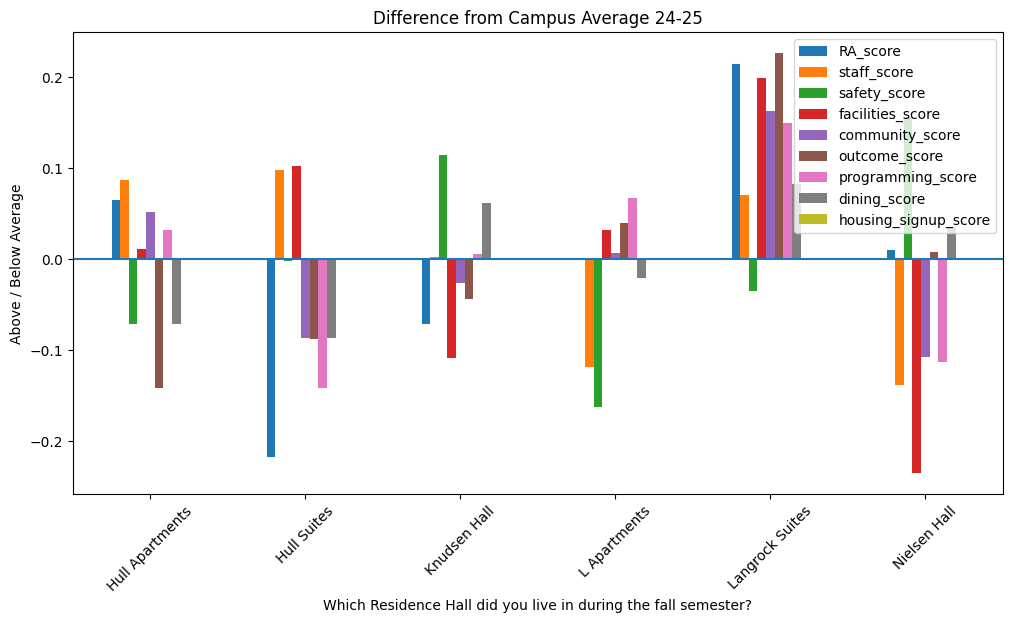

In [64]:
hall_scores = (
    df2.groupby('Which Residence Hall did you live in during the fall semester?')[score_cols]
      .mean()
      .sort_index()
)
diff = hall_scores - hall_scores.mean()

diff.plot(kind='bar', figsize=(12,6))
plt.axhline(0)
plt.title("Difference from Campus Average 24-25")
plt.ylabel("Above / Below Average")
plt.xticks(rotation=45)
plt.show()

In [57]:
# L Apartments and Knudsen have droppoed in all scores this year.
# 
# Nielsen and Hull apartments have gotten better. And Hull Suits have stayed roughly 
# the same. 
# has improved, in addition

In [58]:
df2['Please read the following statements regarding Residence Life programming and rate them. [I would be more likely to stay on campus over the weekend if programs / events were provided more often on Friday / Saturday]'].mean()

# Still a decent amount of demand of weekend programming. 

np.float64(3.761006289308176)

In [59]:
df2["meal_plan_clean"] = df2["What meal plan do you have?"].apply(normalize_meal_plan)
df2["meal_plan_clean"].value_counts(dropna=False)

meal_plan_clean
All Access 5    122
Block 50         63
NaN              60
All Access 7     53
Block 100        13
Block 160         6
Commuter 80       1
Name: count, dtype: int64

In [60]:
df2.groupby('meal_plan_clean')['I am satisfied with my meal plan'].mean().sort_values(ascending=True)

meal_plan_clean
Block 50        3.507937
All Access 5    3.606557
Block 100       3.615385
All Access 7    4.038462
Block 160       4.500000
Commuter 80     5.000000
Name: I am satisfied with my meal plan, dtype: float64

In [61]:
# Almost every category of meal plan's satisfaction score has decreased this year. 
dining_cols = [
    "Please read the following statement regarding GV Dining and rate. [I feel satisfied with the food quality on campus]",
    "Please read the following statement regarding GV Dining and rate. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]",
    "Please read the following statement regarding GV Dining and rate. [I feel satisfied with the variety & quality of food provided in GV Express]",
    "Please read the following statement regarding GV Dining and rate. [I feel satisfied with the variety & quality of options provided at Einstein's Bagels]",
    "Please read the following statement regarding GV Dining and rate. [I feel satisfied with the level of customer service I receive from GV Dining employees]"
]
df2[dining_cols].mean().sort_values()

KeyError: "None of [Index(['Please read the following statement regarding GV Dining and rate. [I feel satisfied with the food quality on campus]',\n       'Please read the following statement regarding GV Dining and rate. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]',\n       'Please read the following statement regarding GV Dining and rate. [I feel satisfied with the variety & quality of food provided in GV Express]',\n       'Please read the following statement regarding GV Dining and rate. [I feel satisfied with the variety & quality of options provided at Einstein's Bagels]',\n       'Please read the following statement regarding GV Dining and rate. [I feel satisfied with the level of customer service I receive from GV Dining employees]'],\n      dtype='object')] are in the [columns]"

In [ ]:
# More complaints about the variety and quality of the food provided on campus. 

: 

In [62]:
col = 'What are the main areas that positively impact your sense of belonging/connection to Grand View University?'

belonging = (
    df2[[col, 'community_score']]
    .dropna(subset=[col])
    .assign(area=lambda d: d[col].str.split(','))
    .explode('area')
)

belonging['area'] = belonging['area'].str.strip()

belonging.groupby('area')['community_score'] \
    .agg(['mean','count']) \
    .sort_values('mean', ascending=False)


# Looking at which impacts having the sense of belonging the most.

# Very strong signals
# Close friendships remain the strongest belonging driver, indicating peer bonds are central to connection.
# Campus Ministry involvement shows a high association, suggesting faith-based community provides meaningful support.
# Residential community experience continues to be a major anchor for connection among students.
# REC/SAC participation and campus location reflect the importance of shared spaces and structured engagement.
# Staff relationships and intramural participation reinforce belonging through frequent interaction and team dynamics.

# Less strong signals
# Campush fellowship/walnut creek 
# roomates/friends 
# Having a mentor (decreased from last year, I'd be interested
# to know more about our moentorship programs and how they 
# change from year to year.)

# 4 at risk people, no sense of belonging on campus 

# Key takeaways
# Belonging is strongest where peer relationships and intentional communities intersect.
# Residential life and faith-based involvement appear more influential this year than broader extracurriculars.
# Physical spaces and shared activities remain essential for fostering connection.
# Structured staff and peer interactions continue to reinforce students’ sense of support.

KeyError: "['What are the main areas that positively impact your sense of belonging/connection to Grand View University?'] not in index"

In [ ]:
df2.columns

Index(['What is your Class Status?',
       'How many semesters have you lived on campus at Grand View?',
       'Are you currently 21 or older?',
       'Do you participate on a Grand View Athletic team?',
       'Which Residence Hall did you live in during the fall semester?',
       'What floor did you live on during the fall semester?',
       'Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of

In [ ]:
col = 'What are the main areas that positively impact your sense of belonging / connection to Grand View University'

belonging = (
    df2[[col, 'community_score']]
    .dropna(subset=[col])
    .assign(area=lambda d: d[col].str.split(','))
    .explode('area')
)

belonging['area'] = belonging['area'].str.strip()

belonging.groupby('area')['community_score'] \
    .agg(['mean','count']) \
    .sort_values('mean', ascending=False)


,mean,count
area,,
Having a mentor on campus,4.459184,14
Your residential community,4.267081,46
Participating in REC/SAC events,4.250000,52
Positive relationships with your coaches,4.238095,102
Participating in intramural sports,4.222222,18
Involvement in an athletic team,4.122024,192
Campus Size,4.120690,116
Campus Location,4.114719,66
Your campus job,4.065637,37


In [ ]:
# Notable are residential community, campus location, rec/sac events, 
# positive relationship with staff, involvement in student leadership & in major 

In [ ]:
df2.groupby('How many residence life programs/events did you attend this school year')['community_score'].mean()

How many residence life programs/events did you attend this school year
1-2 events    3.958525
3-4 events    4.294833
5+ events     4.121212
Name: community_score, dtype: float64

In [ ]:
# Again, we see that increased involvement in residents life programs/events 
# is associated with higher community scores, year over year, for our 2 
# sample years. 

# 25-26 Analysis

Rate-like columns: 55
Unmapped rate-like columns: 0
RA_score items: 8 | total non-numeric cells coerced to NaN: 0
staff_score items: 6 | total non-numeric cells coerced to NaN: 0
programming_score items: 4 | total non-numeric cells coerced to NaN: 0
safety_score items: 5 | total non-numeric cells coerced to NaN: 0
facilities_score items: 7 | total non-numeric cells coerced to NaN: 0
community_score items: 7 | total non-numeric cells coerced to NaN: 0
dining_score items: 5 | total non-numeric cells coerced to NaN: 0
housing_signup_score items: 5 | total non-numeric cells coerced to NaN: 51
outcome_score items: 8 | total non-numeric cells coerced to NaN: 0
Total responses: 137
Belonging column: On a scale of 1-10 how would you rate your sense of belonging/connection to Grand View University


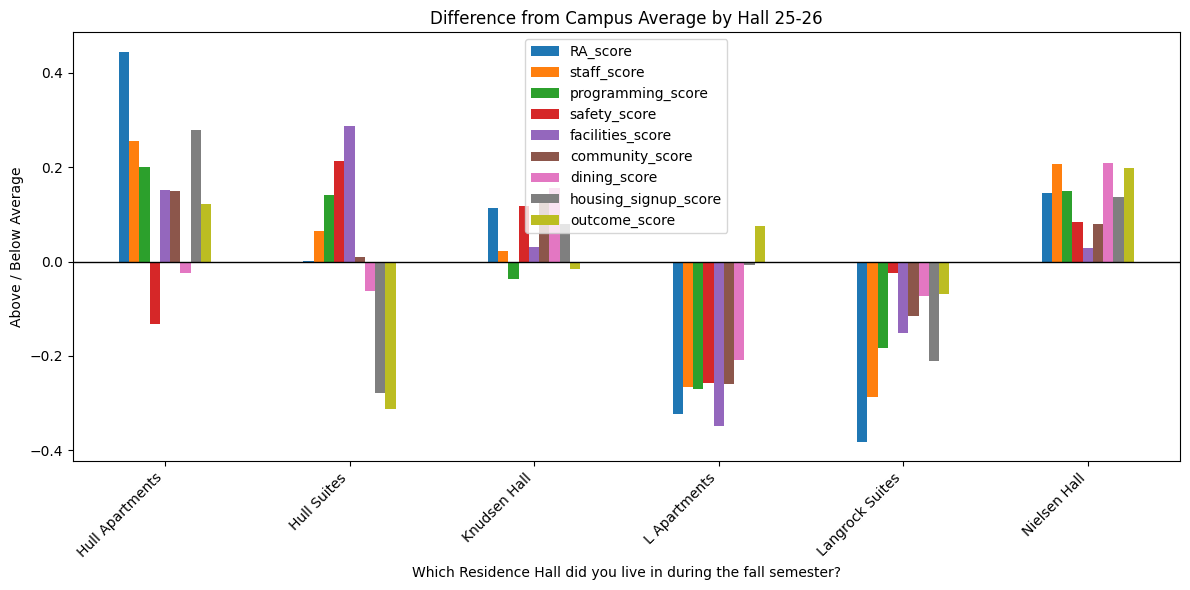

Open-ended columns: 15


In [66]:
# === 25-26 analysis ===
import re
import numpy as np
import pandas as pd

# Define helpers if they are not already available from the 24-25 section
if "convert_likert_columns" not in globals():
    likert_map = {
        "strongly disagree": 1,
        "disagree": 2,
        "neutral": 3,
        "agree": 4,
        "strongly agree": 5,
        "not applicable": np.nan,
        "n/a": np.nan,
        "na": np.nan,
    }

    def standardize_likert(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float, np.integer, np.floating)):
            return float(x)
        s = str(x).strip().lower()
        return likert_map.get(s, np.nan if s in likert_map else x)

    def convert_likert_columns(df):
        out = df.copy()
        for c in out.columns:
            if out[c].dtype == "object":
                out[c] = out[c].map(standardize_likert)
        return out

    DOMAIN_RULES = {
        "RA_score": [
            r"regarding you fall semester ra and rate them",
            r"regarding your fall semester ra and rate them",
        ],
        "staff_score": [r"residence life staff and rate them"],
        "programming_score": [r"residence life programming and rate them"],
        "safety_score": [r"regarding safety and rate them"],
        "facilities_score": [r"residence life facilities\s*&\s*services and rate them"],
        "community_score": [r"regarding the community on campus and rate them"],
        "dining_score": [r"regarding gv dining and rate"],
        "housing_signup_score": [r"housing sign-up process and rate them"],
        "outcome_score": [r"regarding the outcome of living on campus and rate them"],
    }

    def find_domain_columns(columns, patterns):
        cols = []
        for col in columns:
            col_l = str(col).strip().lower()
            for pat in patterns:
                if re.search(pat, col_l):
                    cols.append(col)
                    break
        return cols

    def add_composite_scores(df, min_items=2):
        out = df.copy()
        domain_cols = {}

        for domain, patterns in DOMAIN_RULES.items():
            cols = find_domain_columns(out.columns, patterns)
            domain_cols[domain] = cols

            if len(cols) >= min_items:
                numeric_block = out[cols].apply(pd.to_numeric, errors="coerce")
                out[domain] = numeric_block.mean(axis=1)
            else:
                out[domain] = np.nan

        score_cols = list(DOMAIN_RULES.keys())
        return out, domain_cols, score_cols

if "find_first_column" not in globals():
    def find_first_column(columns, patterns):
        for col in columns:
            col_l = str(col).strip().lower()
            for pat in patterns:
                if re.search(pat, col_l):
                    return col
        return None

if "find_open_ended_columns" not in globals():
    OPEN_ENDED_PATTERNS = [
        r"please share",
        r"please provide",
        r"please explain",
        r"comments",
        r"feedback",
        r"why",
        r"what could",
        r"what do you",
        r"tell us",
    ]

    def find_open_ended_columns(df):
        cols = []
        for c in df.columns:
            if df[c].dtype != "object":
                continue
            cl = str(c).lower()
            if any(re.search(pat, cl) for pat in OPEN_ENDED_PATTERNS):
                cols.append(c)
        return cols

df25_raw = df_25_26.copy()
df25 = convert_likert_columns(df25_raw)
df25, domain_cols_25_26, score_cols_25_26 = add_composite_scores(df25, min_items=2)

# Validate mapping for 25-26 against all rate-type items
matched_cols_25 = set()
for cols in domain_cols_25_26.values():
    matched_cols_25.update(cols)

rate_like_25 = [
    c for c in df25.columns
    if re.search(r"rate them|rate\.", str(c).lower())
 ]
unmapped_rate_like_25 = sorted(set(rate_like_25) - matched_cols_25)

print("Rate-like columns:", len(rate_like_25))
print("Unmapped rate-like columns:", len(unmapped_rate_like_25))
if unmapped_rate_like_25:
    print("Unmapped:")
    for c in unmapped_rate_like_25:
        print("-", c)

for k, cols in domain_cols_25_26.items():
    if len(cols) == 0:
        print(k, "0 items matched")
    else:
        non_numeric = df25[cols].apply(lambda s: pd.to_numeric(s, errors="coerce")).isna().sum().sum()
        print(k, "items:", len(cols), "| total non-numeric cells coerced to NaN:", int(non_numeric))

print("Total responses:", len(df25))

df25[score_cols_25_26].mean().sort_values()

belonging_col_25 = find_first_column(
    df25.columns,
    [r"sense of belonging", r"belonging/connection", r"belonging connection", r"rate your sense of belonging"],
)
if belonging_col_25:
    print("Belonging column:", belonging_col_25)
    df25.corr(numeric_only=True)[belonging_col_25].sort_values(ascending=False)
else:
    print("No belonging question found in 25-26.")

hall_col_25 = find_first_column(
    df25.columns,
    [r"which residence hall", r"residence hall did you live"],
)
if hall_col_25:
    hall_scores_25 = df25.groupby(hall_col_25)[score_cols_25_26].mean().sort_index()
    diff_25 = hall_scores_25 - hall_scores_25.mean()

    diff_25.plot(kind="bar", figsize=(12, 6))
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Difference from Campus Average by Hall 25-26")
    plt.ylabel("Above / Below Average")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    hall_scores_25
    df25[hall_col_25].value_counts(dropna=False)
else:
    print("No residence hall column found in 25-26.")

open_ended_cols_25 = find_open_ended_columns(df25)
print("Open-ended columns:", len(open_ended_cols_25))
if len(open_ended_cols_25) > 0:
    open_ended_counts_25 = df25[open_ended_cols_25].notna().sum().sort_values(ascending=False)
    open_ended_counts_25.head(10)
else:
    print("No open-ended columns found in 25-26.")

# Comparing all 3 years

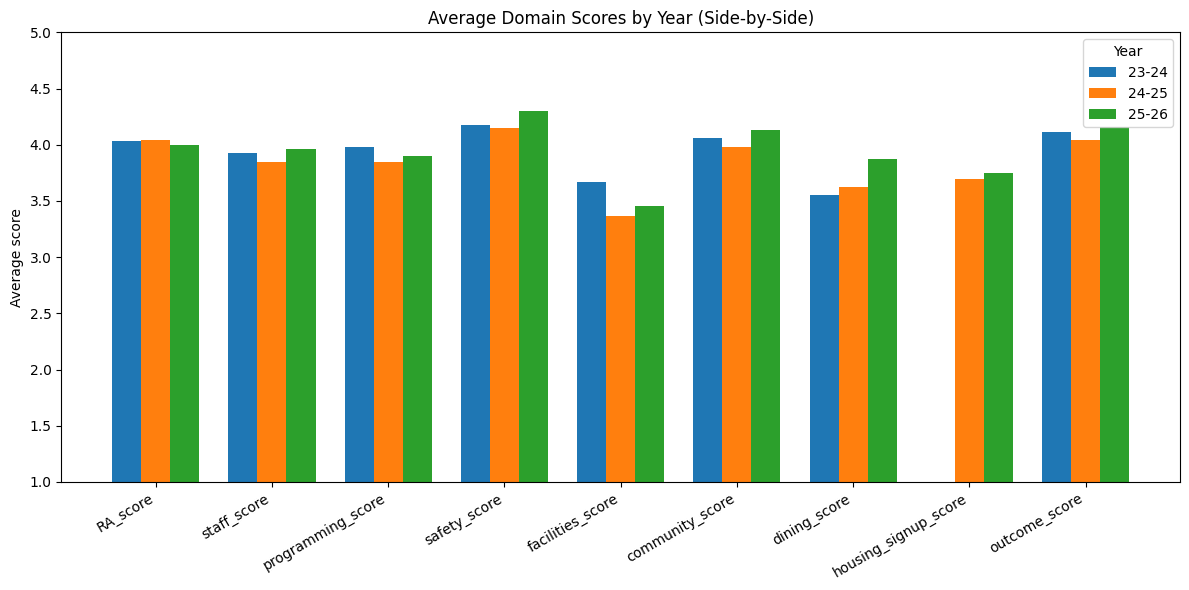

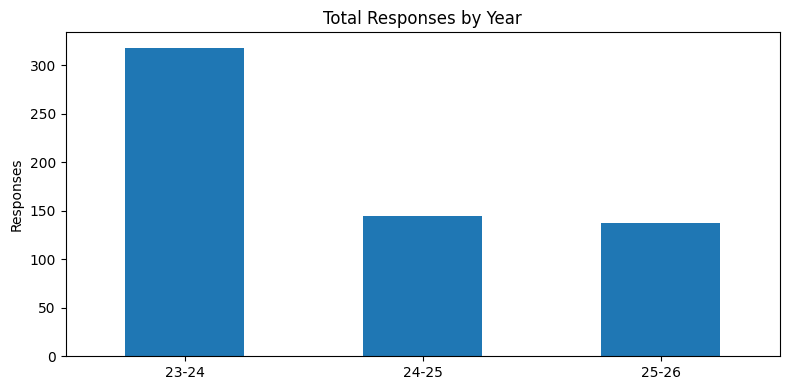

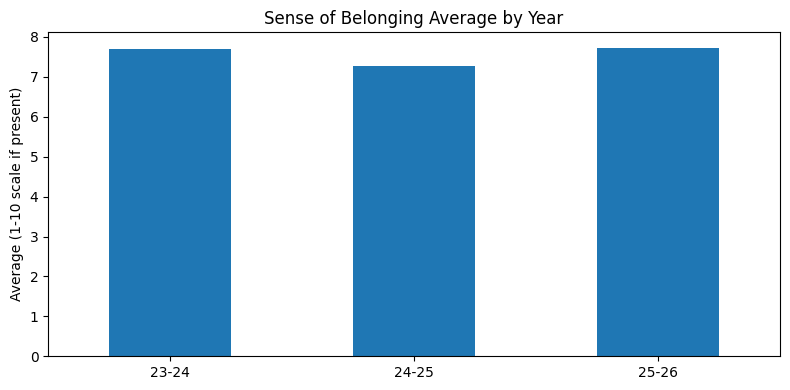

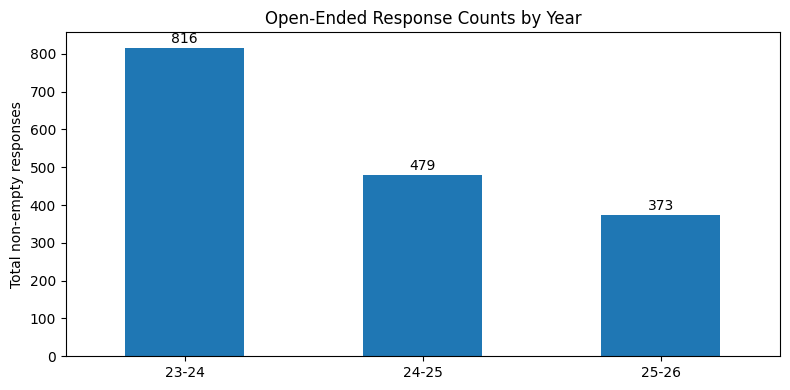


23-24 top open-ended questions (by response count):
What do you enjoy most about living on campus?                                                                                                          185
What do you dislike about living on campus?                                                                                                             156
Please provide any suggestions on what Grand View could do to improve/update any physical space in the residence halls.                                  92
Please provide any additional feedback.                                                                                                                  65
Please share any additional comments about your experience with your RA or any other RAs.                                                                60
Please provide any additional feedback regarding campus safety, maintenance, or facilities.                                                              46
Please prov

In [68]:
# === Comparing all 3 years ===

# Keep the 23-24 cleanup consistent with the earlier section
drop_cols_23_24 = [
    "Timestamp",
    "Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!   By submitting your name below you will receive an additional point for the 2023-2024 Housing Lottery.",
    "Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!   By submitting your name below you will receive an additional point for the 2023-2024 Housing Lottery..1",
]

df_23_24_clean = df_23_24.drop(columns=drop_cols_23_24, errors="ignore")

year_defs = {
    "23-24": df_23_24_clean,
    "24-25": df_24_25,
    "25-26": df_25_26,
}

year_data = {}
for label, raw in year_defs.items():
    df_year = convert_likert_columns(raw.copy())
    df_year, domain_cols, score_cols = add_composite_scores(df_year, min_items=2)
    year_data[label] = {
        "df": df_year,
        "domain_cols": domain_cols,
        "score_cols": score_cols,
    }

score_order = [k for k in DOMAIN_RULES.keys()]
score_means = pd.DataFrame({
    label: data["df"][score_order].mean()
    for label, data in year_data.items()
}).T
score_means

# Side-by-side bar chart: score types on x, colors by year
score_means_long = score_means[score_order].reset_index().melt(
    id_vars="index",
    value_vars=score_order,
    var_name="score_type",
    value_name="score_mean",
)
score_means_long = score_means_long.rename(columns={"index": "year"})

fig, ax = plt.subplots(figsize=(12, 6))
for i, year in enumerate(score_means_long["year"].unique()):
    data = score_means_long[score_means_long["year"] == year]
    ax.bar(
        [x + i * 0.25 for x in range(len(score_order))],
        data["score_mean"],
        width=0.25,
        label=year,
    )

ax.set_xticks([x + 0.25 for x in range(len(score_order))])
ax.set_xticklabels(score_order, rotation=30, ha="right")
ax.set_title("Average Domain Scores by Year (Side-by-Side)")
ax.set_ylabel("Average score")
ax.set_ylim(1, 5)
ax.legend(title="Year")
plt.tight_layout()
plt.show()

response_counts = pd.Series({label: len(data["df"]) for label, data in year_data.items()})
response_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Total Responses by Year")
plt.ylabel("Responses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

def find_belonging_column(columns):
    return find_first_column(
        columns,
        [r"sense of belonging", r"belonging/connection", r"belonging connection", r"rate your sense of belonging"],
    )

belonging_means = {}
for label, data in year_data.items():
    col = find_belonging_column(data["df"].columns)
    if col:
        belonging_means[label] = data["df"][col].mean()

belonging_means = pd.Series(belonging_means)
belonging_means

if not belonging_means.empty:
    belonging_means.plot(kind="bar", figsize=(8, 4))
    plt.title("Sense of Belonging Average by Year")
    plt.ylabel("Average (1-10 scale if present)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No belonging question found across years.")

def open_ended_summary(df):
    cols = find_open_ended_columns(df)
    if len(cols) == 0:
        return pd.Series({"open_ended_questions": 0, "open_ended_responses": 0})
    total = df[cols].notna().sum().sum()
    return pd.Series({
        "open_ended_questions": len(cols),
        "open_ended_responses": int(total),
    })

open_summary = pd.DataFrame({
    label: open_ended_summary(data["df"])
    for label, data in year_data.items()
}).T
open_summary

ax = open_summary["open_ended_responses"].plot(kind="bar", figsize=(8, 4))
plt.title("Open-Ended Response Counts by Year")
plt.ylabel("Total non-empty responses")
plt.xticks(rotation=0)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

for label, data in year_data.items():
    cols = find_open_ended_columns(data["df"])
    if len(cols) == 0:
        print(f"{label}: no open-ended columns found")
        continue
    counts = data["df"][cols].notna().sum().sort_values(ascending=False).head(10)
    print(f"\n{label} top open-ended questions (by response count):")
    print(counts)

In [77]:
df_23_24['Which Residence Hall did you live in during the fall semester?'].value_counts()

Which Residence Hall did you live in during the fall semester?
Langrock Suites    76
Hull Suites        72
L Apartments       71
Nielsen Hall       38
Hull Apartments    32
Knudsen Hall       29
Name: count, dtype: int64

In [76]:
df_24_25['Which Residence Hall did you live in during the fall semester?'].value_counts()

Which Residence Hall did you live in during the fall semester?
L Apartments       42
Langrock Suites    27
Hull Apartments    26
Hull Suites        23
Knudsen Hall       18
Nielsen Hall        9
Name: count, dtype: int64

In [75]:
df_25_26['Which Residence Hall did you live in during the fall semester?'].value_counts()

Which Residence Hall did you live in during the fall semester?
L Apartments       45
Hull Suites        26
Langrock Suites    24
Knudsen Hall       20
Nielsen Hall       12
Hull Apartments    10
Name: count, dtype: int64

C:\Users\bdupey\AppData\Local\Temp\ipykernel_35388\2936024848.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


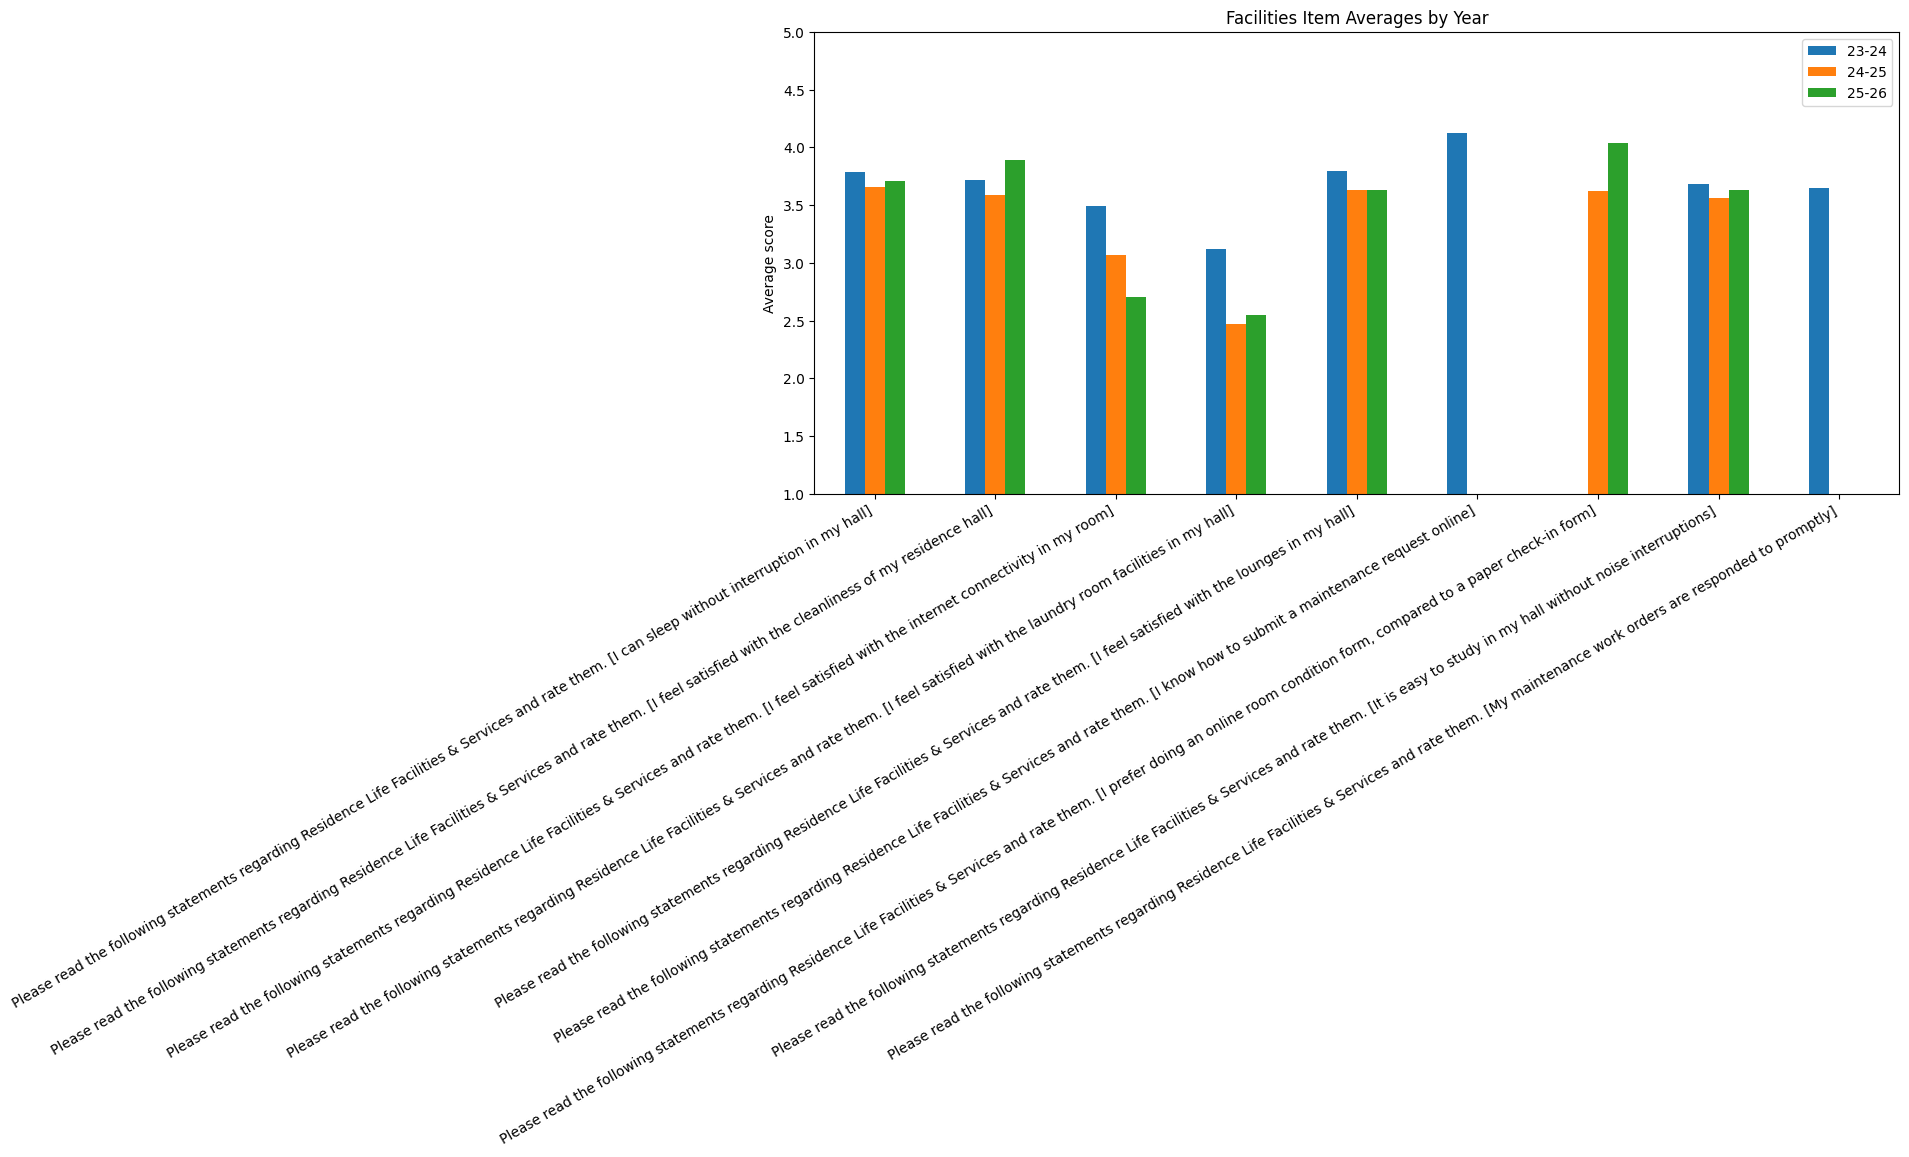

C:\Users\bdupey\AppData\Local\Temp\ipykernel_35388\2936024848.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


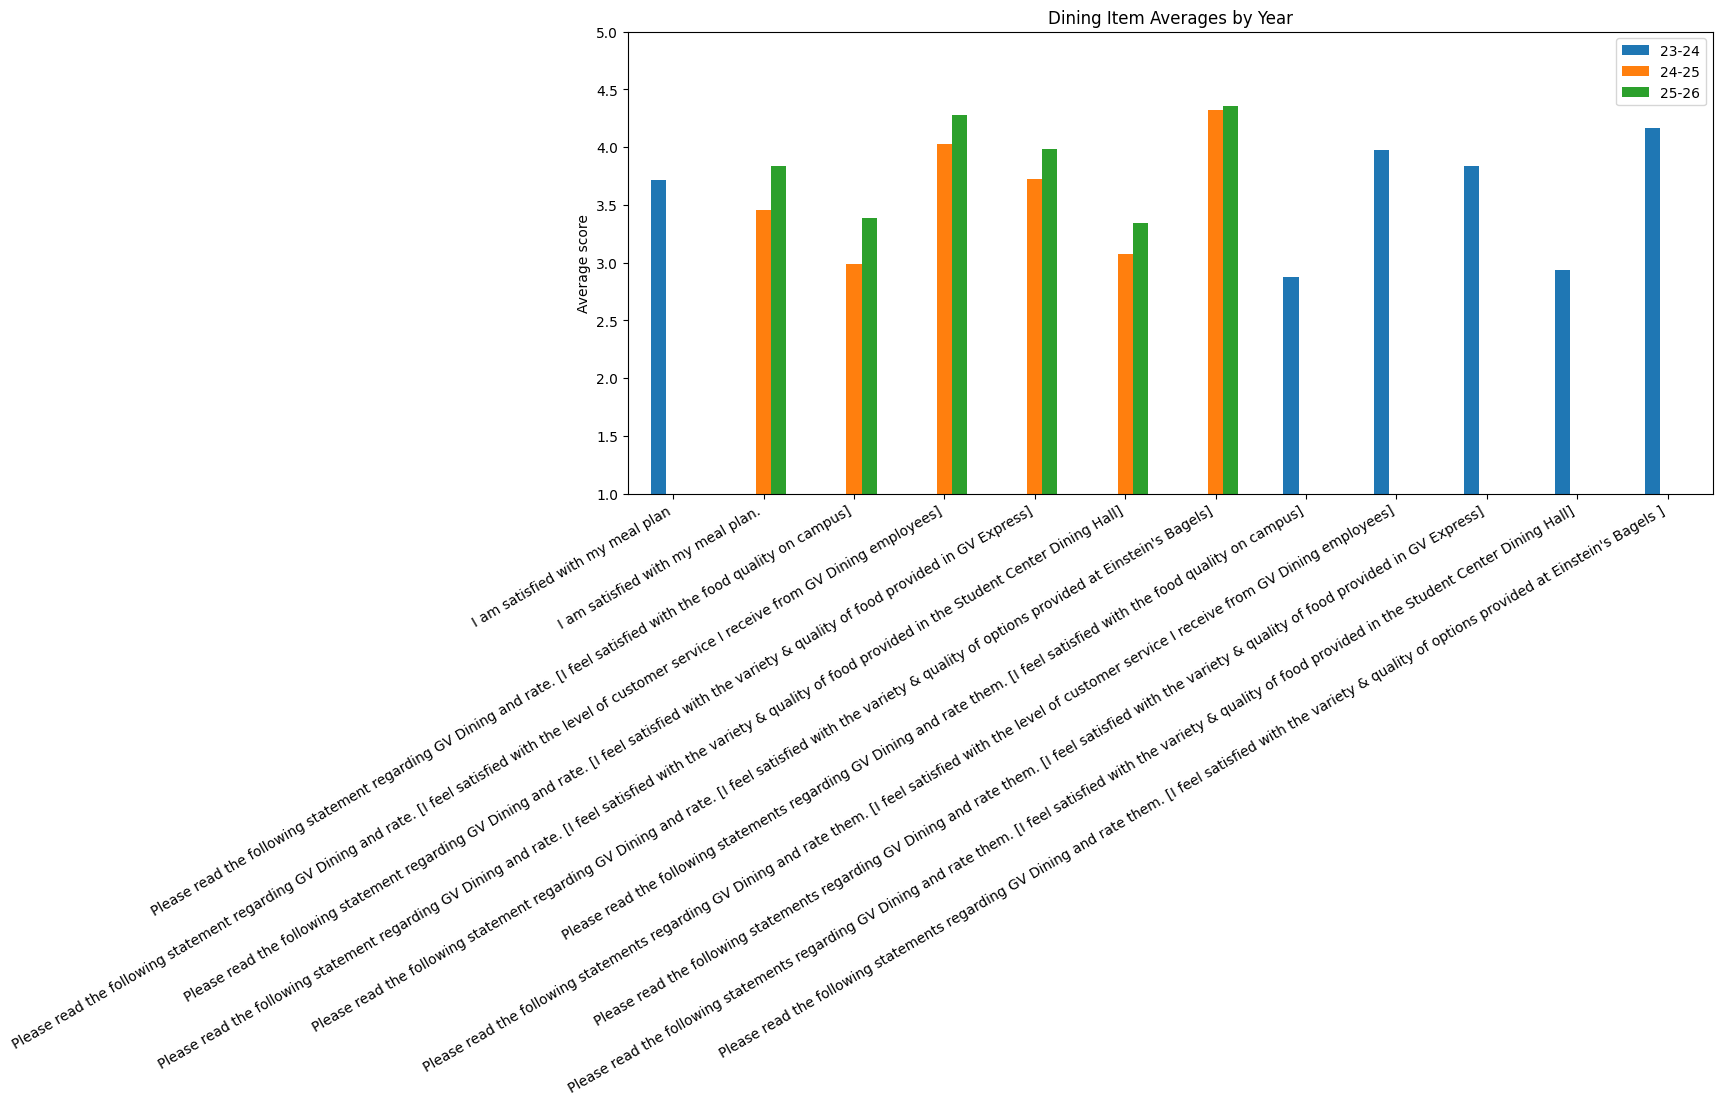

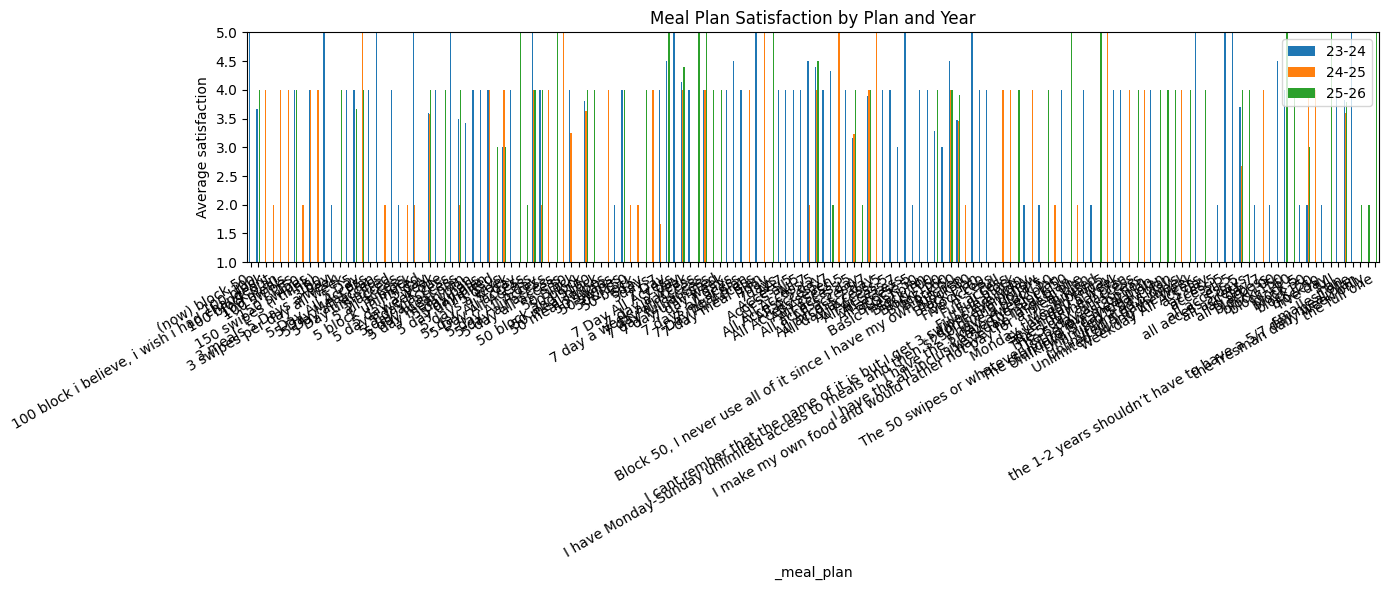


23-24 dining open-ended counts:
What meal plan do you have?                                         273
Describe your ideal meal plan.                                      190
What food items would you like to see served in the dining hall?    147
Please provide any additional feedback on GV Dining.                 18
dtype: int64


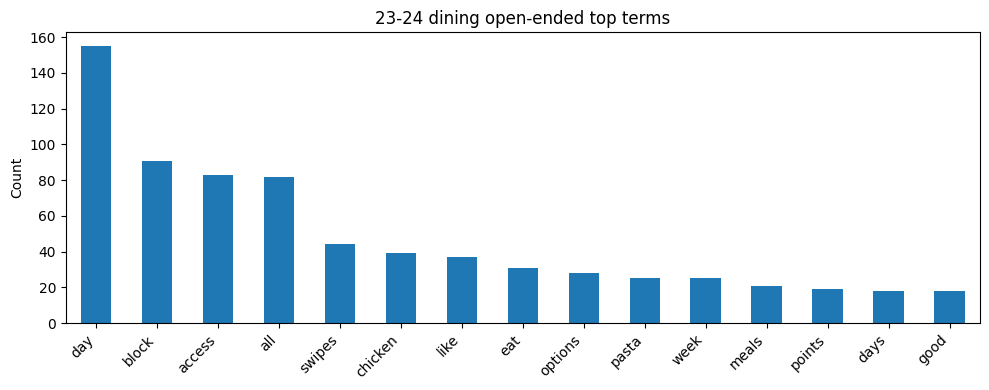


24-25 dining open-ended counts:
What meal plan do you have?                                         113
Describe your ideal meal plan                                        84
What food items would you like to see served in the dining hall?     65
Please provide any additional feedback on GV dining.                 18
dtype: int64


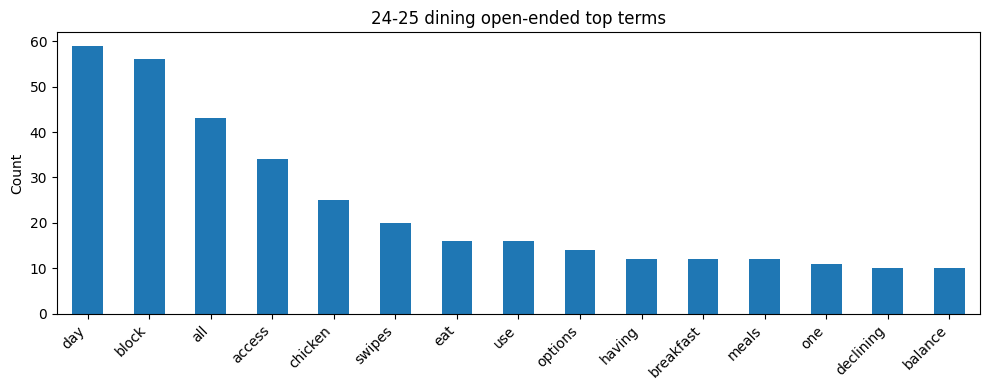


25-26 dining open-ended counts:
What meal plan do you have?                                         109
Describe your ideal meal plan                                        76
What food items would you like to see served in the dining hall?     56
Please provide any additional feedback on GV dining.                  7
dtype: int64


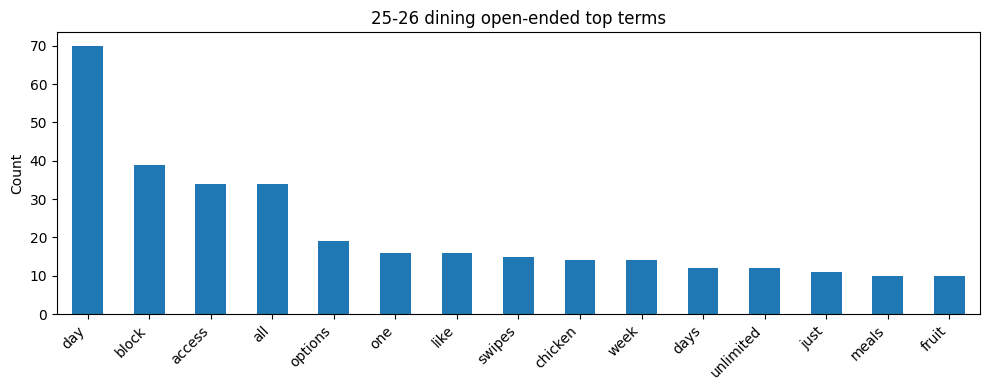

C:\Users\bdupey\AppData\Local\Temp\ipykernel_35388\2936024848.py:137: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


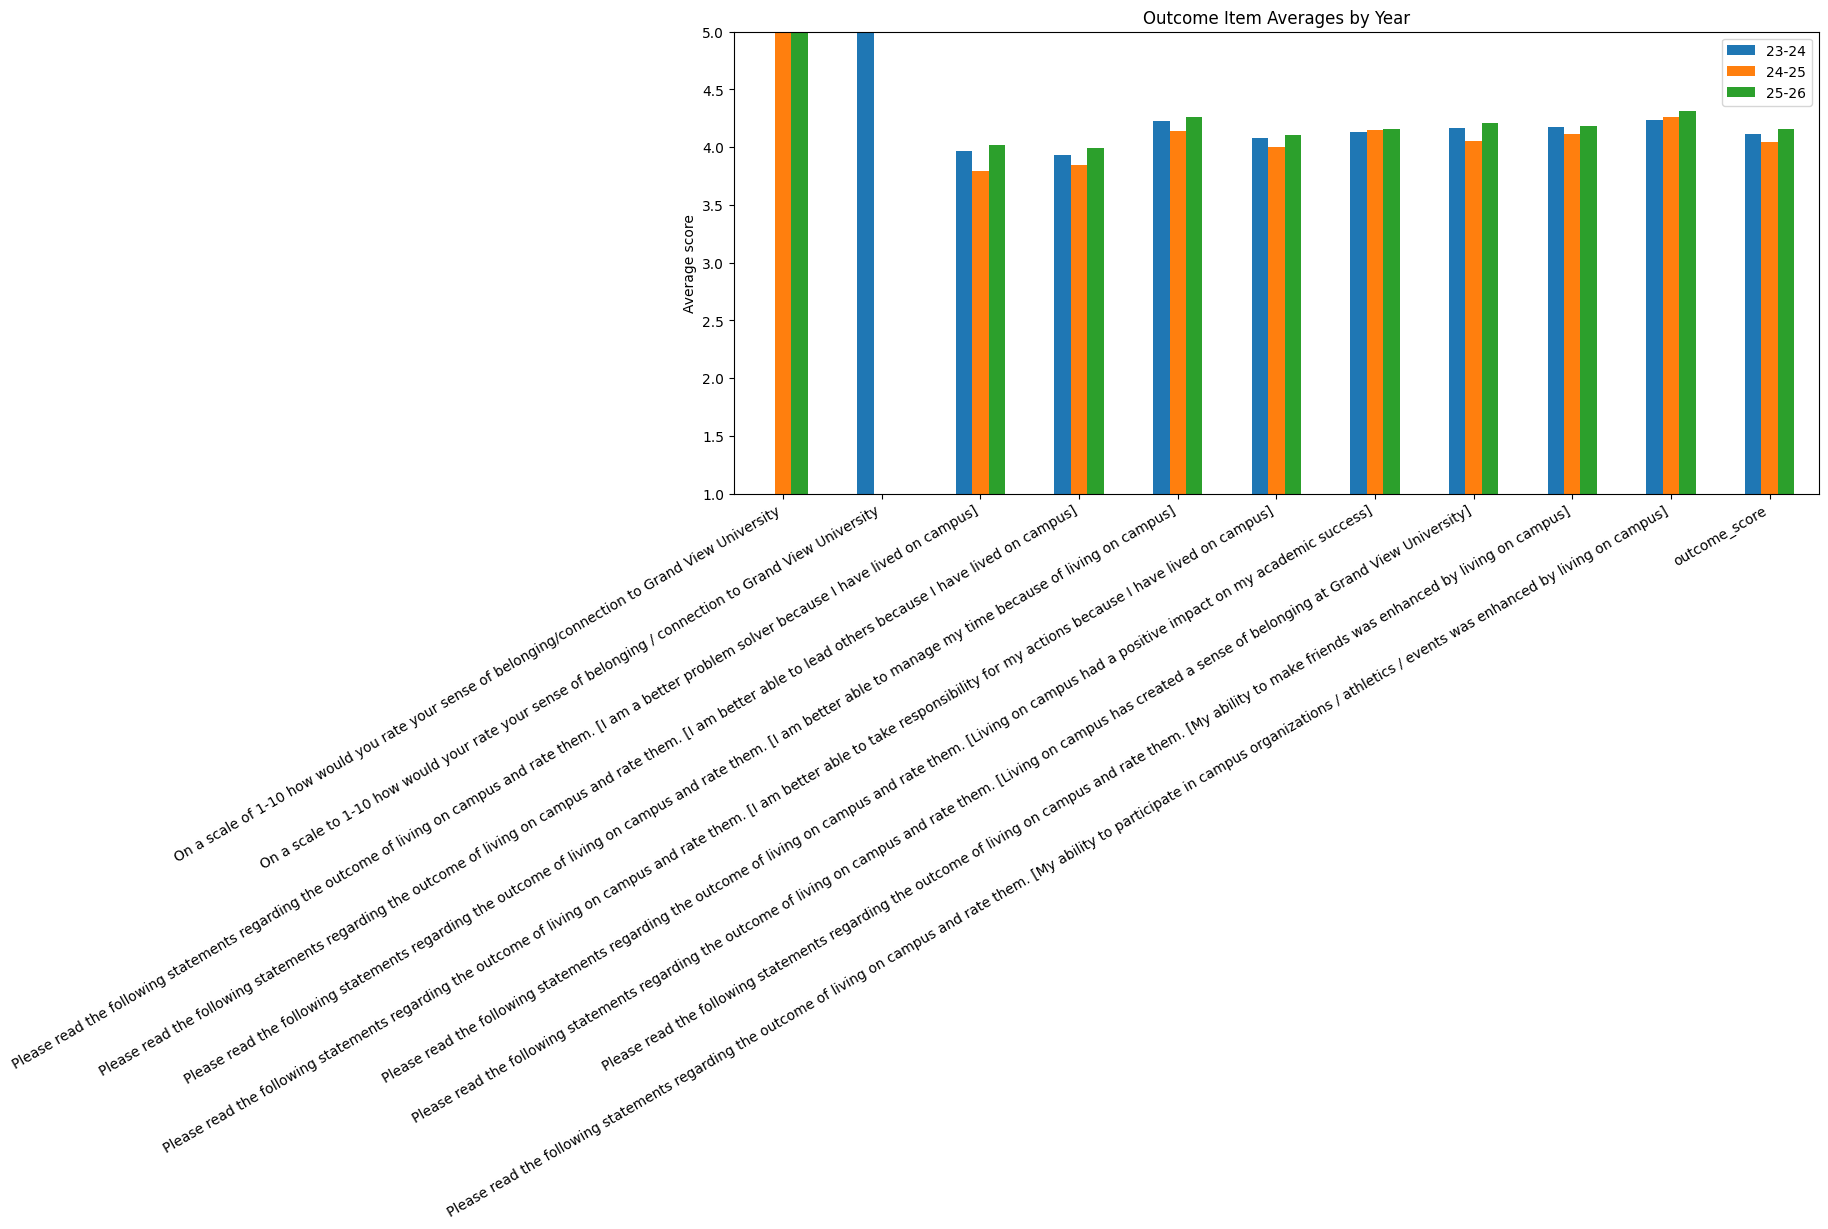

In [ ]:
# === Drivers of changes across years (facilities, dining, outcome) ===

def find_columns_by_patterns(columns, patterns):
    cols = []
    for col in columns:
        col_l = str(col).strip().lower()
        if any(re.search(pat, col_l) for pat in patterns):
            cols.append(col)
    return cols

# Facilities item drivers by year
fac_patterns = [r"facilities\s*&\s*services", r"facilities and services", r"maintenance", r"physical space"]
fac_by_year = {}
for label, data in year_data.items():
    df_year = data["df"]
    fac_cols = find_columns_by_patterns(df_year.columns, fac_patterns)
    fac_cols = [c for c in fac_cols if df_year[c].dtype != "object"]
    if fac_cols:
        fac_by_year[label] = df_year[fac_cols].mean()

if fac_by_year:
    fac_df = pd.DataFrame(fac_by_year).sort_index()
    fac_df.plot(kind="bar", figsize=(14, 6))
    plt.title("Facilities Item Averages by Year")
    plt.ylabel("Average score")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()
else:
    print("No facilities items found across years.")

# Dining item drivers by year
dining_patterns = [r"gv dining", r"dining hall", r"gv express", r"einstein", r"food quality", r"customer service", r"meal plan"]
dining_by_year = {}
for label, data in year_data.items():
    df_year = data["df"]
    dining_cols = find_columns_by_patterns(df_year.columns, dining_patterns)
    dining_cols = [c for c in dining_cols if df_year[c].dtype != "object"]
    if dining_cols:
        dining_by_year[label] = df_year[dining_cols].mean()

if dining_by_year:
    dining_df = pd.DataFrame(dining_by_year).sort_index()
    dining_df.plot(kind="bar", figsize=(14, 6))
    plt.title("Dining Item Averages by Year")
    plt.ylabel("Average score")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()
else:
    print("No dining items found across years.")

# Meal plan satisfaction by year and meal plan (when available)
meal_plan_cols = [
    "What meal plan do you have?",
    "I am satisfied with my meal plan.",
    "I am satisfied with my meal plan",
]
meal_plan_summary = {}
for label, data in year_data.items():
    df_year = data["df"]
    mp_col = find_first_column(df_year.columns, [r"what meal plan do you have"])
    sat_col = find_first_column(df_year.columns, [r"satisfied with my meal plan"])
    if mp_col and sat_col:
        mp_clean = df_year[mp_col].astype(str).str.strip()
        tmp = df_year.assign(_meal_plan=mp_clean)
        meal_plan_summary[label] = tmp.groupby("_meal_plan")[sat_col].mean()

if meal_plan_summary:
    meal_plan_df = pd.DataFrame(meal_plan_summary).sort_index()
    meal_plan_df.plot(kind="bar", figsize=(14, 6))
    plt.title("Meal Plan Satisfaction by Plan and Year")
    plt.ylabel("Average satisfaction")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()
else:
    print("Meal plan satisfaction columns not found across years.")

# Dining open-ended responses (counts and common terms)
stopwords = {
    "the", "and", "to", "of", "a", "in", "for", "is", "it", "with", "on", "that", "this", "be", "are", "was", "as", "at", "have", "has", "had", "i", "we", "you", "they", "my", "our", "your", "their", "but", "or", "so", "if", "not", "very", "more", "less", "from", "an", "by", "about", "would", "could", "should", "food", "dining", "meal", "plan"
}

def top_terms(series, top_n=15):
    text = series.dropna().astype(str).str.lower()
    words = text.str.findall(r"[a-z']+")
    all_words = [w for sublist in words for w in sublist if w not in stopwords and len(w) > 2]
    if not all_words:
        return pd.Series(dtype=int)
    return pd.Series(all_words).value_counts().head(top_n)

for label, data in year_data.items():
    df_year = data["df"]
    dining_open_cols = find_columns_by_patterns(
        df_year.columns,
        [r"dining", r"food", r"meal plan", r"einstein", r"express", r"dining hall"],
    )
    dining_open_cols = [c for c in dining_open_cols if df_year[c].dtype == "object"]
    if not dining_open_cols:
        print(f"{label}: no dining open-ended columns found")
        continue
    open_counts = df_year[dining_open_cols].notna().sum().sort_values(ascending=False)
    print(f"\n{label} dining open-ended counts:")
    print(open_counts)

    combined = df_year[dining_open_cols].astype(str).replace("nan", np.nan)
    term_counts = top_terms(combined.stack())
    if not term_counts.empty:
        term_counts.plot(kind="bar", figsize=(10, 4))
        plt.title(f"{label} dining open-ended top terms")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

# Outcome item drivers by year
outcome_patterns = [r"outcome of living on campus", r"living on campus had a positive impact", r"outcome", r"sense of belonging"]
outcome_by_year = {}
for label, data in year_data.items():
    df_year = data["df"]
    outcome_cols = find_columns_by_patterns(df_year.columns, outcome_patterns)
    outcome_cols = [c for c in outcome_cols if df_year[c].dtype != "object"]
    if outcome_cols:
        outcome_by_year[label] = df_year[outcome_cols].mean()

if outcome_by_year:
    outcome_df = pd.DataFrame(outcome_by_year).sort_index()
    outcome_df.plot(kind="bar", figsize=(14, 6))
    plt.title("Outcome Item Averages by Year")
    plt.ylabel("Average score")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()
else:
    print("No outcome items found across years.")

# Comparing the two years 